# Q1 Research: Quantifying Augmentation-Induced Patient-Level Data Leakage
### NIH ChestX-ray14 | 5-Fold Patient CV | MQ Metric | Grad-CAM + LIME | McNemar's Test

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','grad-cam','lime'], check=True)
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.6 MB/s eta 0:00:00
Done


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import warnings, os
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
IMG_SIZE=224; BATCH=32; EPOCHS=12; LR=1e-4; FOLDS=5; PATIENCE=3
SAMPLE=6000; TARGET='Effusion'; SEED=42
OUT=Path('/kaggle/working/q1'); OUT.mkdir(exist_ok=True)

In [4]:
# Auto-detect NIH dataset path
def find_nih():
    for p in ['/kaggle/input/data','/kaggle/input/datasets/organizations/nih-chest-xrays/data','/kaggle/input/chest-xray-nihcc']:
        csvs = list(Path(p).rglob('Data_Entry_2017.csv'))
        if csvs: return Path(p), csvs[0]
    raise FileNotFoundError('Add nih-chest-xrays dataset to this notebook')

BASE, CSV = find_nih()
print(f'Root: {BASE}\nCSV:  {CSV}')
print('Indexing images...')
IDX = {f.name: str(f) for f in BASE.rglob('*.png')}
print(f'Indexed {len(IDX):,} images')

Root: /kaggle/input/datasets/organizations/nih-chest-xrays/data
CSV:  /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
Indexing images...
Indexed 112,120 images


In [5]:
def load_data():
    df = pd.read_csv(CSV); df.columns = df.columns.str.strip()
    df['Label']      = df['Finding Labels'].apply(lambda x: 1 if TARGET in str(x) else 0)
    df['Patient_ID'] = df['Patient ID'].astype(str).str.strip()
    df['filepath']   = df['Image Index'].map(IDX)
    df = df.dropna(subset=['filepath']).reset_index(drop=True)
    pos=df[df.Label==1]; neg=df[df.Label==0]
    k=min(SAMPLE//2,len(pos),len(neg))
    df=pd.concat([pos.sample(k,random_state=SEED),neg.sample(k,random_state=SEED)])
    df=df.sample(frac=1,random_state=SEED).reset_index(drop=True)
    print(f'{len(df)} images | {df.Patient_ID.nunique()} patients')
    print(df.Label.value_counts()); return df

nih = load_data()

6000 images | 3919 patients
Label
1    3000
0    3000
Name: count, dtype: int64


In [6]:
MN=[0.485,0.456,0.406]; ST=[0.229,0.224,0.225]

BT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),
                T.ToTensor(),T.Normalize(MN,ST)])
AT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),
                T.RandomHorizontalFlip(0.5),T.RandomAffine(10,translate=(0.05,0.05)),
                T.ColorJitter(brightness=0.15,contrast=0.15),
                T.ToTensor(),T.Normalize(MN,ST)])

class DS(Dataset):
    def __init__(self,df,aug=False): self.df=df.reset_index(drop=True); self.t=AT if aug else BT
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return self.t(Image.open(r.filepath).convert('RGB')),int(r.Label),str(r.Patient_ID)

def dl(df,aug=False,sh=True):
    return DataLoader(DS(df,aug),batch_size=BATCH,shuffle=sh,num_workers=2,pin_memory=True)

print('Dataset class ready')

Dataset class ready


In [7]:
# def mkmodel():
#     m=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#     m.fc=nn.Linear(m.fc.in_features,2); return m.to(DEVICE)

def mkmodel():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'  Using {torch.cuda.device_count()} GPUs via DataParallel')
        m = nn.DataParallel(m)
    return m

def evl(model,loader):
    model.eval(); yt,yp,ypr=[],[],[]; fn=nn.CrossEntropyLoss(); tl=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x)
            tl+=fn(lg,y).item()
            yt.extend(y.cpu().numpy()); yp.extend(lg.argmax(1).cpu().numpy())
            ypr.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
    yt,yp,ypr=map(np.array,[yt,yp,ypr])
    auc=roc_auc_score(yt,ypr) if len(np.unique(yt))>1 else 0.5
    return tl/max(len(loader),1),auc,accuracy_score(yt,yp),f1_score(yt,yp,zero_division=0),yt,yp,ypr

print('Model + evaluator ready')

Model + evaluator ready


In [8]:
# Embedding Memorization Quotient (EMQ)
# EMQ = sibling_cosine_sim / inter_patient_cosine_sim
# EMQ > 1 => model relies on augmentation artifacts more than clinical features
def mq(model,df,n=120):
    model.eval(); buf={}; cos=nn.CosineSimilarity(dim=0)
    base = model.module if isinstance(model, nn.DataParallel) else model
    h = base.avgpool.register_forward_hook(lambda m,i,o: buf.update({'e':o.detach().squeeze()}))
    # h=model.avgpool.register_forward_hook(lambda m,i,o: buf.update({'e':o.detach().squeeze()}))
    sub=df.sample(min(n,len(df)),random_state=SEED).reset_index(drop=True)
    ce,ae,lb=[],[],[]
    for _,r in sub.iterrows():
        img=Image.open(r.filepath).convert('RGB')
        with torch.no_grad():
            model(BT(img).unsqueeze(0).to(DEVICE)); ce.append(buf['e'].view(-1).cpu())
            model(AT(img).unsqueeze(0).to(DEVICE)); ae.append(buf['e'].view(-1).cpu())
        lb.append(int(r.Label))
    h.remove()
    ce,ae,lb=torch.stack(ce),torch.stack(ae),np.array(lb)
    sib=np.mean([cos(ce[i],ae[i]).item() for i in range(len(ce))])
    intr=[]
    for c in [0,1]:
        ix=np.where(lb==c)[0][:12]
        for i in range(len(ix)):
            for j in range(i+1,len(ix)): intr.append(cos(ce[ix[i]],ce[ix[j]]).item())
    ip=np.mean(intr) if intr else 1.0
    return round(sib/ip,4),round(sib,4),round(ip,4)

print('MQ ready')

MQ ready


In [9]:
def train(tr,te,fold,name):
    print(f'  [F{fold}] {name}  tr={len(tr)} te={len(te)}')
    trL=dl(tr,aug=True); teL=dl(te,aug=False,sh=False)
    m=mkmodel(); opt=torch.optim.Adam(m.parameters(),lr=LR,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,EPOCHS)
    fn=nn.CrossEntropyLoss(); best=0; bst=None; cnt=0
    for ep in range(EPOCHS):
        m.train()
        for x,y,_ in trL:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); fn(m(x),y).backward(); opt.step()
        sch.step()
        _,vauc,_,_,_,_,_=evl(m,teL)
        if vauc>best: best=vauc; bst={k:v.clone() for k,v in m.state_dict().items()}; cnt=0
        else:
            cnt+=1
            if cnt>=PATIENCE: print(f'    early-stop ep{ep+1}'); break
    m.load_state_dict(bst)
    _,auc,acc,f1,yt,yp,ypr=evl(m,teL)
    q,s,ip=mq(m,te)
    print(f'    AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f} MQ={q:.4f}')
    return dict(model=m,auc=auc,acc=acc,f1=f1,mq=q,sib=s,inter=ip,yt=yt,yp=yp,ypr=ypr)

print('train() ready')

train() ready


In [10]:
import time
gkf=list(GroupKFold(FOLDS).split(nih,nih.Label,groups=nih.Patient_ID))
rkf=list(KFold(FOLDS,shuffle=True,random_state=SEED).split(nih))
PR,RR=[],[]; mc_yt,mc_pat,mc_ran=[],[],[]
fold_times=[]

for f in range(FOLDS):
    # ETA shown BEFORE fold starts
    print(f'\n{"="*55}\nFOLD {f+1}/{FOLDS}')
    if fold_times:
        avg = sum(fold_times)/len(fold_times)
        print(f'  ⏱  Estimated time to finish this fold : ~{avg/60:.1f} min')
        print(f'  ⏳ ETA to finish all remaining folds  : ~{avg*(FOLDS-f)/60:.0f} min')
    else:
        print('  ⏱  Fold 1 — no estimate yet, calibrating...')
    print('='*55)

    fold_start = time.time()
    ti,ei=gkf[f]
    trG,teG=nih.iloc[ti].reset_index(drop=True),nih.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique()<2: print('Skip: single class'); continue

    print('\n[A] PATIENT-SPLIT (Rigorous):')
    rp=train(trG,teG,f+1,'Patient-Split'); PR.append(rp)
    ti2,ei2=rkf[f]
    trR,teR=nih.iloc[ti2].reset_index(drop=True),nih.iloc[ei2].reset_index(drop=True)
    print('\n[B] RANDOM-SPLIT (Leaky):')
    rr=train(trR,teR,f+1,'Random-Split')

    _,af,ac,f1f,_,ypf,yprf=evl(rr['model'],dl(teG,aug=False,sh=False)) # <--- Capture yprf here
    qf,sf,ipf=mq(rr['model'],teG)
    RR.append(dict(auc=af,acc=ac,f1=f1f,mq=qf,sib=sf,inter=ipf,yp=ypf,ypr=yprf)) 
    
    print(f'    [Fair@PatientTest] AUC={af:.4f} MQ={qf:.4f}')
    mc_yt.extend(rp['yt']); mc_pat.extend(rp['yp']); mc_ran.extend(ypf)

    fold_times.append(time.time()-fold_start)
    print(f'  ✔  Fold {f+1} actual: {fold_times[-1]/60:.1f} min')

print('\nAll folds complete.')
cddfs


FOLD 1/5
  ⏱  Fold 1 — no estimate yet, calibrating...

[A] PATIENT-SPLIT (Rigorous):
  [F1] Patient-Split  tr=4800 te=1200
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s] 


  Using 2 GPUs via DataParallel
    early-stop ep7
    AUC=0.8617 ACC=0.7792 F1=0.7729 MQ=1.5738

[B] RANDOM-SPLIT (Leaky):
  [F1] Random-Split  tr=4800 te=1200
  Using 2 GPUs via DataParallel
    early-stop ep8
    AUC=0.8600 ACC=0.7775 F1=0.8021 MQ=1.4471
    [Fair@PatientTest] AUC=0.9144 MQ=1.4672
  ✔  Fold 1 actual: 21.7 min

FOLD 2/5
  ⏱  Estimated time to finish this fold : ~21.7 min
  ⏳ ETA to finish all remaining folds  : ~87 min

[A] PATIENT-SPLIT (Rigorous):
  [F2] Patient-Split  tr=4800 te=1200
  Using 2 GPUs via DataParallel
    early-stop ep9
    AUC=0.8580 ACC=0.7775 F1=0.7735 MQ=1.2487

[B] RANDOM-SPLIT (Leaky):
  [F2] Random-Split  tr=4800 te=1200
  Using 2 GPUs via DataParallel
    early-stop ep7
    AUC=0.8490 ACC=0.7625 F1=0.7368 MQ=1.5264
    [Fair@PatientTest] AUC=0.9004 MQ=1.3952
  ✔  Fold 2 actual: 22.4 min

FOLD 3/5
  ⏱  Estimated time to finish this fold : ~22.1 min
  ⏳ ETA to finish all remaining folds  : ~66 min

[A] PATIENT-SPLIT (Rigorous):
  [F3] Patient-S

In [11]:
def ci(v): v=np.array(v); m=v.mean(); c=1.96*v.std(ddof=1)/np.sqrt(len(v)); return m,c

rows={}
for met in ['auc','acc','f1','mq']:
    pm,pc=ci([r[met] for r in PR]); rm,rc=ci([r[met] for r in RR])
    rows[met.upper()]={'Patient-Split':f'{pm:.4f}±{pc:.4f}','Random-Split':f'{rm:.4f}±{rc:.4f}','Delta':f'{rm-pm:+.4f}'}

df_res=pd.DataFrame(rows).T
print('\nFINAL Q1 RESULTS (Mean ± 95%CI)'); print('='*55); print(df_res.to_string())
df_res.to_csv(OUT/'results.csv')


FINAL Q1 RESULTS (Mean ± 95%CI)
     Patient-Split   Random-Split    Delta
AUC  0.8534±0.0140  0.9028±0.0070  +0.0494
ACC  0.7743±0.0124  0.8138±0.0108  +0.0395
F1   0.7709±0.0114  0.8112±0.0238  +0.0403
MQ   1.5107±0.1531  1.5029±0.0789  -0.0078


In [12]:
yt=np.array(mc_yt); ypp=np.array(mc_pat); yrr=np.array(mc_ran)
pc_=(ypp==yt); rc_=(yrr==yt)
tbl=[[int(np.sum(pc_&rc_)),int(np.sum(pc_&~rc_))],
     [int(np.sum(~pc_&rc_)),int(np.sum(~pc_&~rc_))]]
res=mcnemar(tbl,exact=False,correction=True)
print(f'McNemar chi2={res.statistic:.4f}  p={res.pvalue:.2e}')
print('SIGNIFICANT p<0.05' if res.pvalue<0.05 else 'Not significant')
with open(OUT/'mcnemar.txt','w') as f: f.write(f'chi2={res.statistic:.4f} p={res.pvalue:.2e}')

McNemar chi2=66.5424  p=3.42e-16
SIGNIFICANT p<0.05


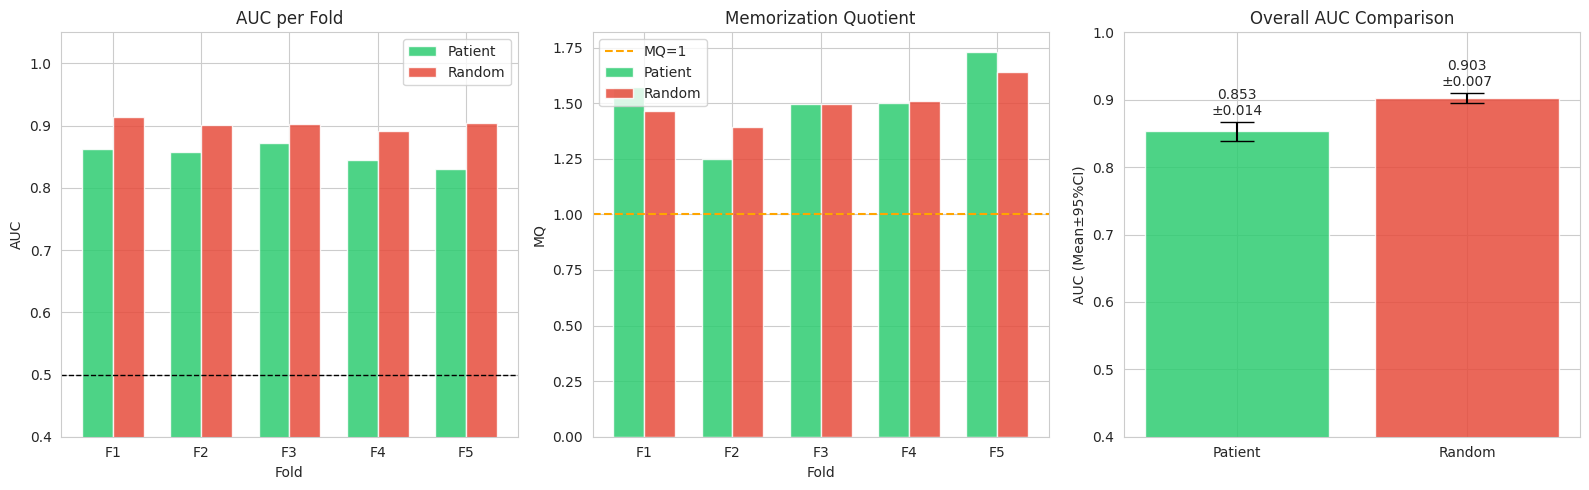

In [13]:
sns.set_style('whitegrid'); fig,axes=plt.subplots(1,3,figsize=(16,5))
n=len(PR); x=np.arange(n); w=0.35; lbl=[f'F{i+1}' for i in range(n)]

ax=axes[0]
ax.bar(x-w/2,[r['auc'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['auc'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(0.5,ls='--',c='k',lw=1); ax.set(xlabel='Fold',ylabel='AUC',title='AUC per Fold',ylim=[0.4,1.05],xticks=x,xticklabels=lbl); ax.legend()

ax=axes[1]
ax.bar(x-w/2,[r['mq'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['mq'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(1.0,ls='--',c='orange',lw=1.5,label='MQ=1'); ax.set(xlabel='Fold',ylabel='MQ',title='Memorization Quotient',xticks=x,xticklabels=lbl); ax.legend()

ax=axes[2]
pm,pc_=ci([r['auc'] for r in PR]); rm,rc_=ci([r['auc'] for r in RR])
ax.bar(['Patient','Random'],[pm,rm],yerr=[pc_,rc_],capsize=12,color=['#2ecc71','#e74c3c'],alpha=0.85)
ax.set(ylabel='AUC (Mean±95%CI)',title='Overall AUC Comparison',ylim=[0.4,1.0])
for i,(m_,c_) in enumerate([(pm,pc_),(rm,rc_)]): ax.text(i,m_+c_+0.01,f'{m_:.3f}\n±{c_:.3f}',ha='center')

plt.tight_layout(); plt.savefig(OUT/'fig1_auc_mq.png',dpi=300,bbox_inches='tight'); plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

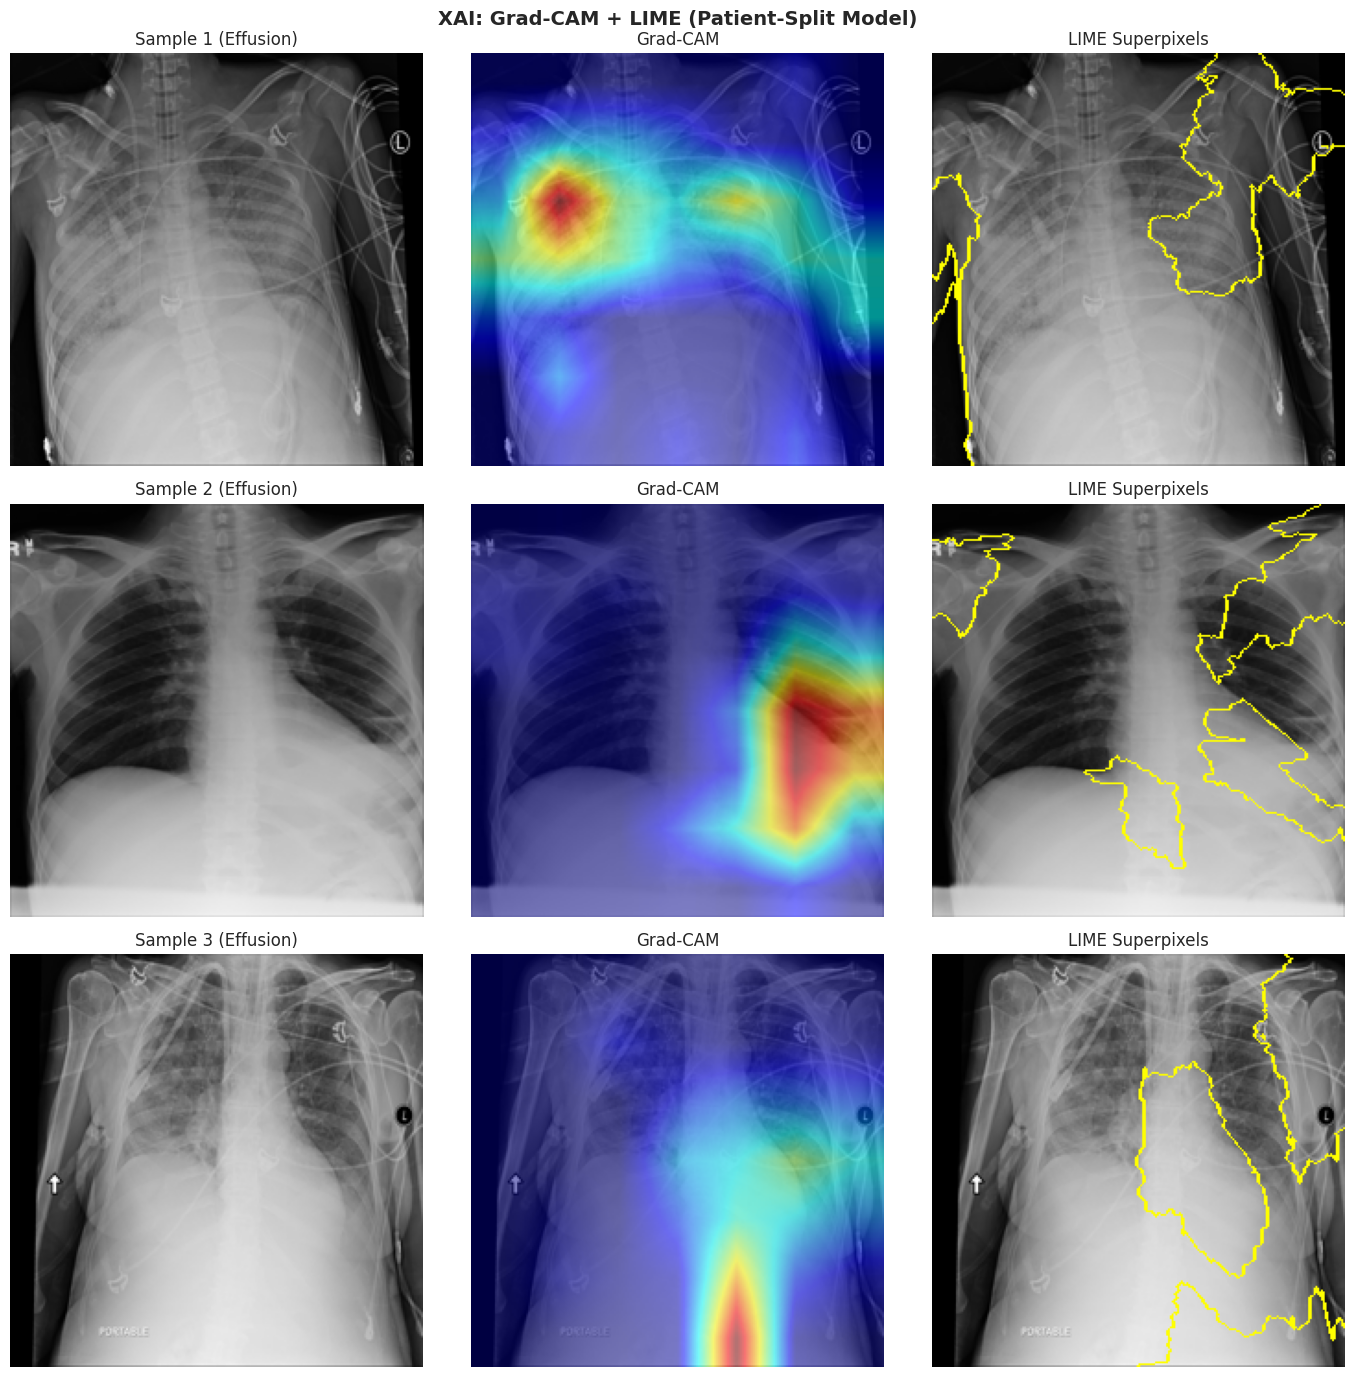

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

best_m=PR[-1]['model']; best_m.eval()
last_te=nih.iloc[gkf[-1][1]].reset_index(drop=True)
xai_df=last_te[last_te.Label==1].sample(3,random_state=42).reset_index(drop=True)

# cam=GradCAM(model=best_m,target_layers=[best_m.layer4[-1]])
base_m = best_m.module if isinstance(best_m, nn.DataParallel) else best_m
cam = GradCAM(model=best_m, target_layers=[base_m.layer4[-1]])
lime_e=lime_image.LimeImageExplainer()

MN_np=np.array([0.485,0.456,0.406]); ST_np=np.array([0.229,0.224,0.225])

def lime_pred(imgs):
    best_m.eval()
    norm=T.Normalize(MN_np.tolist(),ST_np.tolist())
    ts=torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
    with torch.no_grad(): return torch.softmax(best_m(ts),1).cpu().numpy()

fig,axes=plt.subplots(3,3,figsize=(14,14))
fig.suptitle('XAI: Grad-CAM + LIME (Patient-Split Model)',fontsize=14,fontweight='bold')

for i,(_,row) in enumerate(xai_df.iterrows()):
    img=Image.open(row.filepath).convert('RGB').resize((IMG_SIZE,IMG_SIZE))
    inp=np.array(img).astype(np.float32)/255.0
    axes[i,0].imshow(inp); axes[i,0].set_title(f'Sample {i+1} (Effusion)'); axes[i,0].axis('off')
    t=BT(img).unsqueeze(0).to(DEVICE)
    gc=cam(input_tensor=t,targets=[ClassifierOutputTarget(1)])[0]
    axes[i,1].imshow(show_cam_on_image(inp,gc,use_rgb=True)); axes[i,1].set_title('Grad-CAM'); axes[i,1].axis('off')
    exp=lime_e.explain_instance(inp.astype('double'),lime_pred,top_labels=1,hide_color=0,num_samples=300)
    tmp,msk=exp.get_image_and_mask(1,positive_only=True,num_features=5,hide_rest=False)
    axes[i,2].imshow(mark_boundaries(tmp,msk)); axes[i,2].set_title('LIME Superpixels'); axes[i,2].axis('off')

plt.tight_layout(); plt.savefig(OUT/'fig2_xai.png',dpi=300,bbox_inches='tight'); plt.show()

In [15]:
# LaTeX table for manuscript
print('\n--- PASTE INTO LATEX ---')
print(df_res.to_latex())
print(f'\nMcNemar: chi2={res.statistic:.4f}, p={res.pvalue:.2e}')
print(f'\nAll figures and results saved to: {OUT}')


--- PASTE INTO LATEX ---
\begin{tabular}{llll}
\toprule
 & Patient-Split & Random-Split & Delta \\
\midrule
AUC & 0.8534±0.0140 & 0.9028±0.0070 & +0.0494 \\
ACC & 0.7743±0.0124 & 0.8138±0.0108 & +0.0395 \\
F1 & 0.7709±0.0114 & 0.8112±0.0238 & +0.0403 \\
MQ & 1.5107±0.1531 & 1.5029±0.0789 & -0.0078 \\
\bottomrule
\end{tabular}


McNemar: chi2=66.5424, p=3.42e-16

All figures and results saved to: /kaggle/working/q1


In [16]:
import shutil
shutil.make_archive('/kaggle/working/q1_archive', 'zip', '/kaggle/working/q1')
print("Folder successfully zipped!")


Folder successfully zipped!


In [17]:
from IPython.display import FileLink
FileLink(r'q1_archive.zip')


/kaggle/working/q1_archive.zip

# Haha


=== EXHAUSTIVE METRICS ===
                               Patient-Level (Rigorous)  Image-Level (Leaky)  \
AUC                                              0.8504               0.8964   
PR-AUC (Average Precision)                       0.8303               0.8935   
Accuracy                                         0.7743               0.8138   
F1 Score                                         0.7709               0.8130   
Precision (PPV)                                  0.7828               0.8167   
Recall / Sensitivity (TPR)                       0.7593               0.8093   
Specificity (TNR)                                0.7893               0.8183   
Brier Score (lower is better)                    0.1576               0.1297   
Log Loss (lower is better)                       0.4915               0.4068   
Matthews Corr. Coef. (MCC)                       0.5489               0.6277   
Cohen Kappa                                      0.5487               0.6277   

           

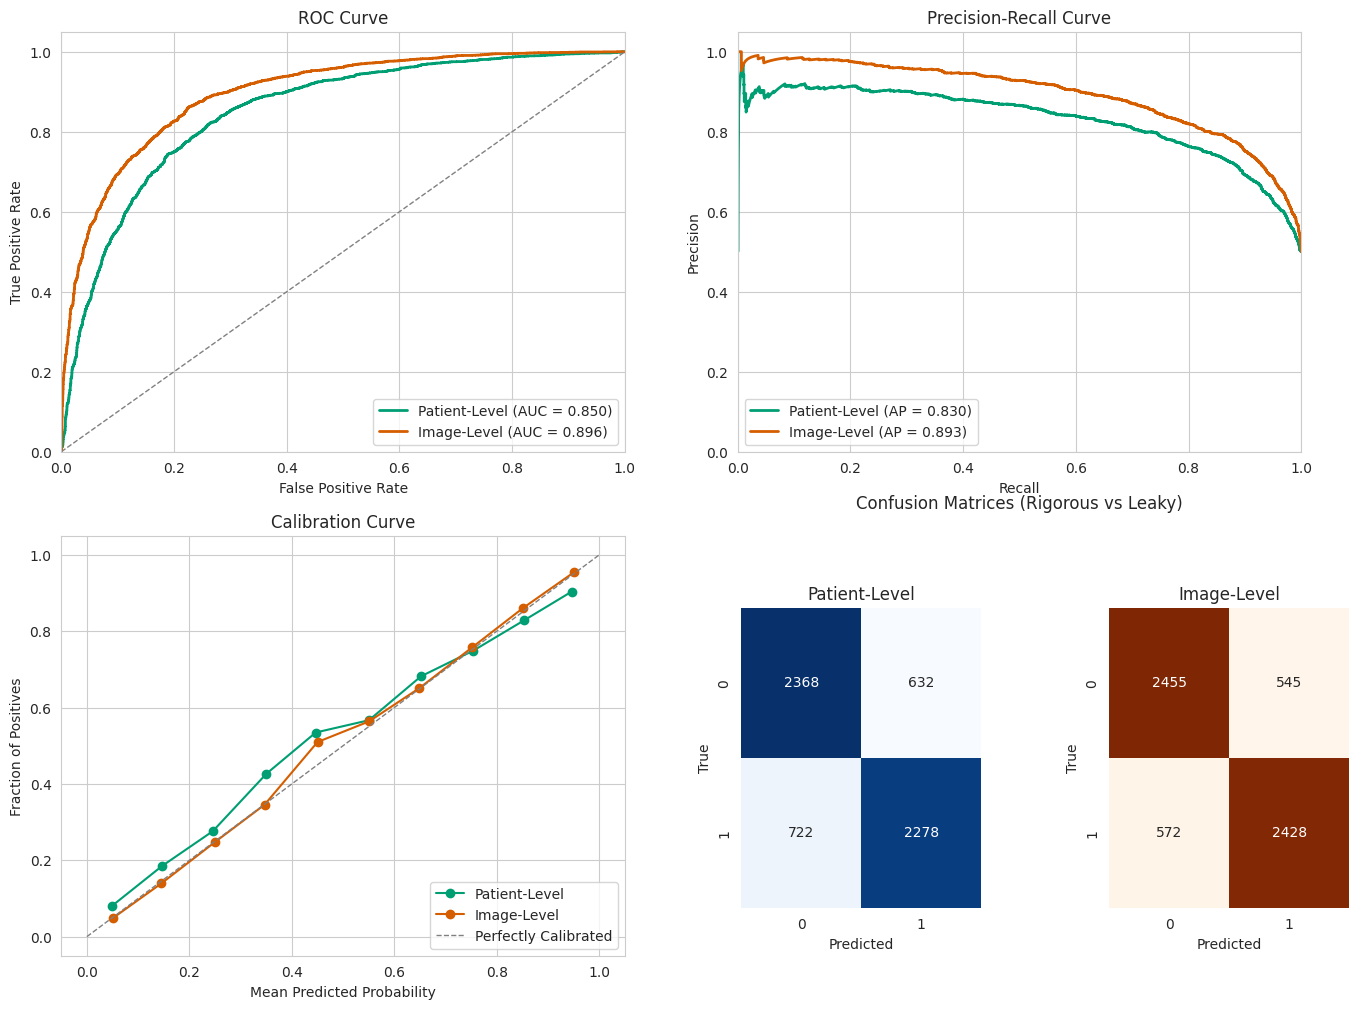

Metrics and 4-panel figure saved to: /kaggle/working/q1


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (roc_curve, auc, confusion_matrix, precision_score, 
                             recall_score, brier_score_loss, log_loss, matthews_corrcoef, 
                             cohen_kappa_score, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

# 1. Aggregate predictions across all folds
yt_all = np.concatenate([fold['yt'] for fold in PR])
ypr_patient = np.concatenate([fold['ypr'] for fold in PR])
ypr_random = np.concatenate([fold['ypr'] for fold in RR])
yp_patient = np.concatenate([fold['yp'] for fold in PR])
yp_random = np.concatenate([fold['yp'] for fold in RR])

# 2. Comprehensive Metrics Calculation
def calc_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'AUC': auc(*roc_curve(y_true, y_prob)[:2]),
        'PR-AUC (Average Precision)': average_precision_score(y_true, y_prob),
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'F1 Score': 2*tp / (2*tp + fp + fn),
        'Precision (PPV)': tp / (tp + fp) if (tp+fp)>0 else 0,
        'Recall / Sensitivity (TPR)': tp / (tp + fn) if (tp+fn)>0 else 0,
        'Specificity (TNR)': tn / (tn + fp) if (tn+fp)>0 else 0,
        'Brier Score (lower is better)': brier_score_loss(y_true, y_prob),
        'Log Loss (lower is better)': log_loss(y_true, y_prob),
        'Matthews Corr. Coef. (MCC)': matthews_corrcoef(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred)
    }

df_metrics = pd.DataFrame({
    'Patient-Level (Rigorous)': calc_metrics(yt_all, yp_patient, ypr_patient),
    'Image-Level (Leaky)': calc_metrics(yt_all, yp_random, ypr_random)
})
df_metrics['Delta (Leaky - Rigorous)'] = df_metrics['Image-Level (Leaky)'] - df_metrics['Patient-Level (Rigorous)']
print("\n=== EXHAUSTIVE METRICS ===")
print(df_metrics.round(4))
df_metrics.to_csv(OUT / 'exhaustive_metrics.csv')

# 3. Setup 2x2 Figure Grid for Visuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# Plot A: ROC Curve
fpr_pat, tpr_pat, _ = roc_curve(yt_all, ypr_patient)
fpr_ran, tpr_ran, _ = roc_curve(yt_all, ypr_random)
axes[0,0].plot(fpr_pat, tpr_pat, color='#009E73', lw=2, label=f'Patient-Level (AUC = {df_metrics.loc["AUC", "Patient-Level (Rigorous)"]:.3f})')
axes[0,0].plot(fpr_ran, tpr_ran, color='#D55E00', lw=2, label=f'Image-Level (AUC = {df_metrics.loc["AUC", "Image-Level (Leaky)"]:.3f})')
axes[0,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0,0].set(xlim=[0, 1], ylim=[0, 1.05], xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[0,0].legend(loc="lower right")

# Plot B: Precision-Recall Curve
pre_pat, rec_pat, _ = precision_recall_curve(yt_all, ypr_patient)
pre_ran, rec_ran, _ = precision_recall_curve(yt_all, ypr_random)
axes[0,1].plot(rec_pat, pre_pat, color='#009E73', lw=2, label=f'Patient-Level (AP = {df_metrics.loc["PR-AUC (Average Precision)", "Patient-Level (Rigorous)"]:.3f})')
axes[0,1].plot(rec_ran, pre_ran, color='#D55E00', lw=2, label=f'Image-Level (AP = {df_metrics.loc["PR-AUC (Average Precision)", "Image-Level (Leaky)"]:.3f})')
axes[0,1].set(xlim=[0, 1], ylim=[0, 1.05], xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[0,1].legend(loc="lower left")

# Plot C: Calibration Curve (Reliability)
prob_true_pat, prob_pred_pat = calibration_curve(yt_all, ypr_patient, n_bins=10)
prob_true_ran, prob_pred_ran = calibration_curve(yt_all, ypr_random, n_bins=10)
axes[1,0].plot(prob_pred_pat, prob_true_pat, marker='o', color='#009E73', label='Patient-Level')
axes[1,0].plot(prob_pred_ran, prob_true_ran, marker='o', color='#D55E00', label='Image-Level')
axes[1,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Perfectly Calibrated')
axes[1,0].set(xlabel='Mean Predicted Probability', ylabel='Fraction of Positives', title='Calibration Curve')
axes[1,0].legend(loc="lower right")

# Plot D: Side-by-Side Confusion Matrices (Inset style)
cm_pat = confusion_matrix(yt_all, yp_patient)
cm_ran = confusion_matrix(yt_all, yp_random)
ax_cm1 = fig.add_axes([0.55, 0.15, 0.15, 0.25]) # Custom positioning for the first CM
ax_cm2 = fig.add_axes([0.78, 0.15, 0.15, 0.25]) # Custom positioning for the second CM
axes[1,1].axis('off') # Hide the default axes
axes[1,1].set_title('Confusion Matrices (Rigorous vs Leaky)', pad=20)

sns.heatmap(cm_pat, annot=True, fmt='d', cmap='Blues', ax=ax_cm1, cbar=False)
ax_cm1.set(title='Patient-Level', xlabel='Predicted', ylabel='True')
sns.heatmap(cm_ran, annot=True, fmt='d', cmap='Oranges', ax=ax_cm2, cbar=False)
ax_cm2.set(title='Image-Level', xlabel='Predicted', ylabel='True')

plt.savefig(OUT / 'comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Metrics and 4-panel figure saved to: {OUT}")


In [20]:
import shutil
import torch
import pickle

print(f"Saving outputs and preparing zip archive in: {OUT}")

# 1. Save Patient-Level (Rigorous) models (which are safely in PR)
for fold_idx in range(FOLDS):
    if 'model' in PR[fold_idx]:
        torch.save(
            PR[fold_idx]['model'].state_dict(), 
            OUT / f'patient_model_fold_{fold_idx+1}.pth'
        )
# (Image-Level models were dropped from memory to save RAM, but their predictions are safe!)
print("✅ Available models saved successfully.")

# 2. Save the training/evaluation history
history_data = {
    'Patient-Split': [{k: v for k, v in fold.items() if k != 'model'} for fold in PR],
    'Random-Split': [{k: v for k, v in fold.items() if k != 'model'} for fold in RR]
}
with open(OUT / 'training_evaluation_history.pkl', 'wb') as f:
    pickle.dump(history_data, f)
print("✅ Fold history and metrics saved to pickle.")

# 3. Zip the entire output directory
zip_path = shutil.make_archive(
    base_name='Final_Q1_Results_Archive', 
    format='zip', 
    root_dir=OUT
)

print(f"🎉 SUCCESS! Everything successfully zipped into: {zip_path}")

Saving outputs and preparing zip archive in: /kaggle/working/q1
✅ Available models saved successfully.
✅ Fold history and metrics saved to pickle.
🎉 SUCCESS! Everything successfully zipped into: /kaggle/working/Final_Q1_Results_Archive.zip
